# DetMCD
## References
- https://arxiv.org/abs/2411.01954
- https://github.com/STAN-UAntwerp/robpy/
- https://robpy.readthedocs.io/en/latest/api/robpy.covariance.html#module-robpy.covariance.mcd

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from robpy.covariance.mcd import DetMCD
from scipy.stats import chi2
from matplotlib.patches import Ellipse

%load_ext autoreload
%autoreload 2

c:\Users\u0159868\.conda\envs\stickybugs\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
Applying consistency correction to the raw covariance estimate
Applying reweighting to the raw covariance estimate
Applying consistency correction after reweighting.


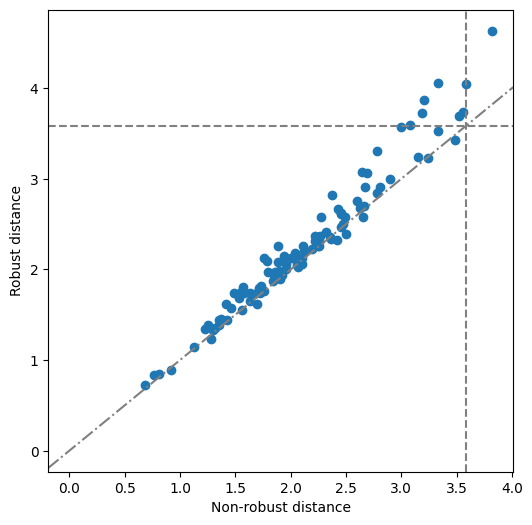

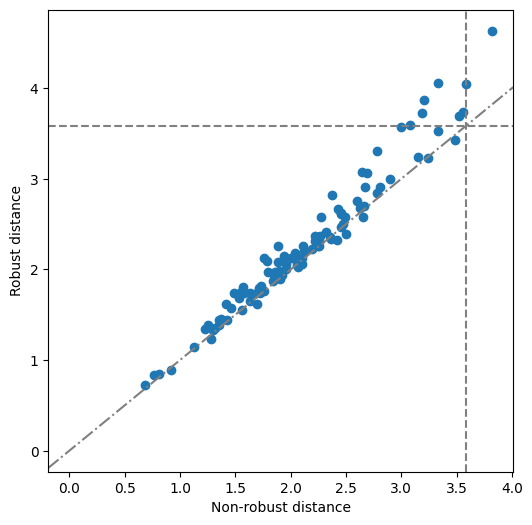

In [2]:
# Generate synthetic data
np.random.seed(42)
X = np.random.randn(100, 5)  # Replace with real data

# Initialize and fit DetMCD
detmcd = DetMCD(alpha=0.75, verbosity=10)
detmcd.fit(X)

# Diagnostic plot
detmcd.distance_distance_plot(chi2_percentile=0.975, figsize=(6, 6))


In [3]:
# Robust location (mean vector)
robust_location = detmcd.location_
print("Robust Location:", robust_location)

# Robust covariance matrix
robust_covariance = detmcd.covariance_
print("Robust Covariance Matrix:\n", robust_covariance)

# Precision matrix (inverse covariance)
precision_matrix = detmcd.precision_
print("Precision Matrix:\n", precision_matrix)

# Mahalanobis distances
mahalanobis_distances = detmcd.mahalanobis(X)
print("Mahalanobis Distances:\n", mahalanobis_distances)


Robust Location: [-0.04500218  0.13746378 -0.11367088  0.10907749 -0.15651787]
Robust Covariance Matrix:
 [[ 0.83717732 -0.16273929 -0.01907894 -0.04557261 -0.07756847]
 [-0.16273929  0.89525984  0.12292825  0.01097991  0.18606761]
 [-0.01907894  0.12292825  0.89419303  0.02487586 -0.06945566]
 [-0.04557261  0.01097991  0.02487586  0.85250733  0.00970622]
 [-0.07756847  0.18606761 -0.06945566  0.00970622  0.8319542 ]]
Precision Matrix:
 [[ 1.24533704e+00  2.11278851e-01  1.07025887e-03  6.30431281e-02
   6.82118841e-02]
 [ 2.11278851e-01  1.23771254e+00 -1.86941293e-01  3.91367699e-03
  -2.72769533e-01]
 [ 1.07025887e-03 -1.86941293e-01  1.15574232e+00 -3.28392850e-02
   1.38779664e-01]
 [ 6.30431281e-02  3.91367699e-03 -3.28392850e-02  1.17741903e+00
  -1.14756420e-02]
 [ 6.82118841e-02 -2.72769533e-01  1.38779664e-01 -1.14756420e-02
   1.28107422e+00]]
Mahalanobis Distances:
 [ 3.49896147  3.59732242  8.47719419  5.08205396  5.33977353  3.02685884
  5.53742953  8.0753745   3.04486595

c:\Users\u0159868\.conda\envs\stickybugs\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


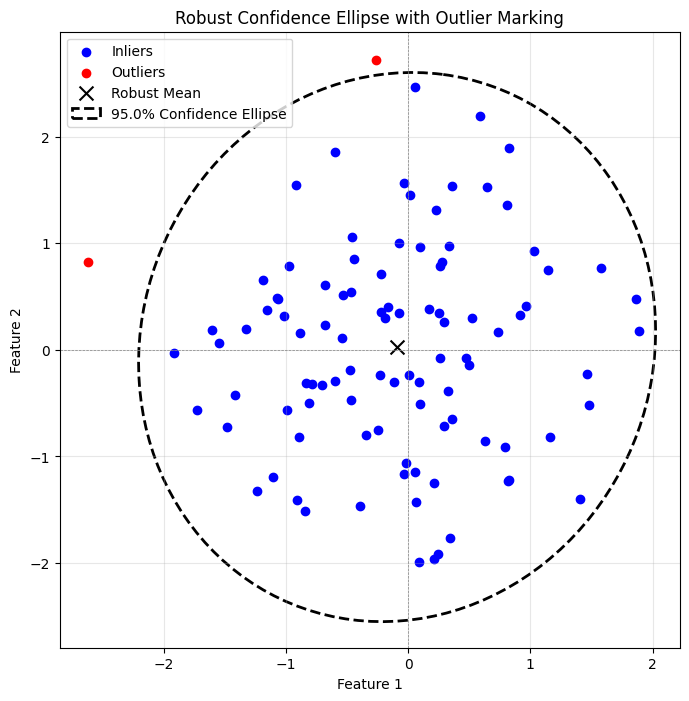

In [4]:
# Generate a synthetic 2D dataset
np.random.seed(42)
X = np.random.randn(100, 2)

# Fit DetMCD
detmcd = DetMCD(alpha=0.75, tolerance=1e-8, correct_covariance=True, reweighting=True)
detmcd.fit(X)

# Robust location and covariance
robust_location = detmcd.location_
robust_covariance = detmcd.covariance_

# Calculate the 95% Chi-squared quantile for 2 degrees of freedom
quantile = 0.95
threshold = chi2.ppf(quantile, df=2)

# Compute Mahalanobis distances
mahalanobis_distances = detmcd.mahalanobis(X)

# Identify outliers
outliers = mahalanobis_distances > threshold

# Compute the ellipse parameters
eigvals, eigvecs = np.linalg.eigh(robust_covariance)
width, height = 2 * np.sqrt(threshold * eigvals)  # Scale eigenvalues for 95% CI
angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))  # Angle of the first eigenvector

# Plot the data
plt.figure(figsize=(8, 8))

# Plot inliers
plt.scatter(X[~outliers, 0], X[~outliers, 1], color='blue', label="Inliers")

# Plot outliers
plt.scatter(X[outliers, 0], X[outliers, 1], color='red', label="Outliers")

# Plot the robust mean
plt.scatter(*robust_location, color="black", marker="x", s=100, label="Robust Mean")

# Add the ellipse
ellipse = Ellipse(
    xy=robust_location, width=width, height=height, angle=angle,
    edgecolor="black", facecolor="none", linestyle="--", linewidth=2, label=f"{quantile*100}% Confidence Ellipse"
)
plt.gca().add_patch(ellipse)

# Plot settings
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.5)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.5)
plt.title("Robust Confidence Ellipse with Outlier Marking")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


c:\Users\u0159868\.conda\envs\stickybugs\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


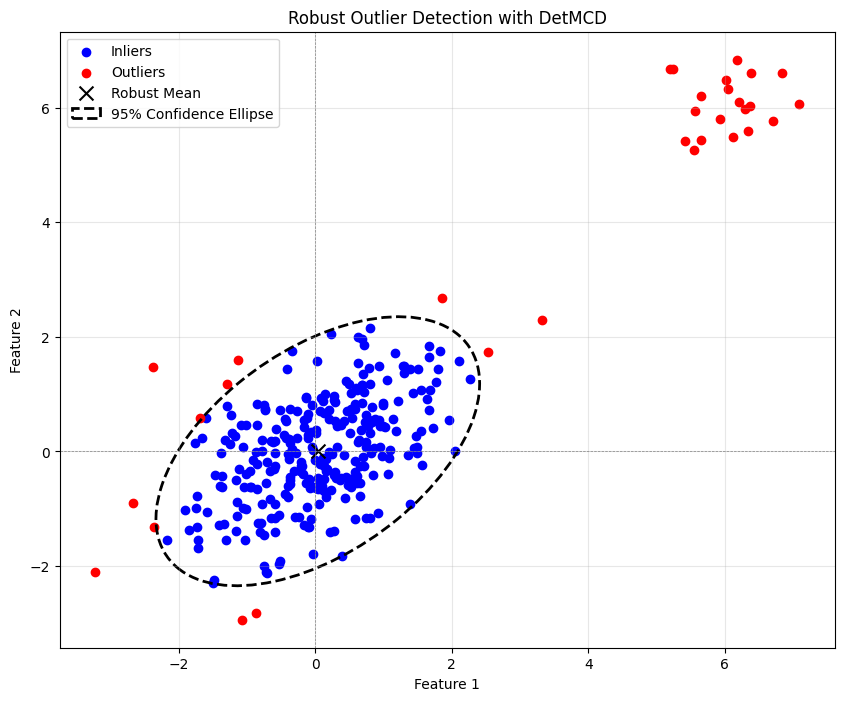

In [5]:
# Generate synthetic data with two clusters
np.random.seed(42)

# Large cluster (inliers)
large_cluster = np.random.multivariate_normal(
    mean=[0, 0],
    cov=[[1, 0.5], [0.5, 1]],
    size=300
)

# Small cluster (outliers)
small_cluster = np.random.multivariate_normal(
    mean=[6, 6],
    cov=[[0.2, 0], [0, 0.2]],
    size=20
)

# Combine the clusters
X = np.vstack([large_cluster, small_cluster])

# Fit DetMCD
detmcd = DetMCD(alpha=0.75, tolerance=1e-8, correct_covariance=True, reweighting=True)
detmcd.fit(X)

# Robust location and covariance
robust_location = detmcd.location_
robust_covariance = detmcd.covariance_

# Calculate the 95% Chi-squared quantile for 2 degrees of freedom
threshold = chi2.ppf(0.95, df=2)

# Compute Mahalanobis distances
mahalanobis_distances = detmcd.mahalanobis(X)

# Identify outliers
outliers = mahalanobis_distances > threshold

# Compute the ellipse parameters
eigvals, eigvecs = np.linalg.eigh(robust_covariance)
width, height = 2 * np.sqrt(threshold * eigvals)  # Scale eigenvalues for 95% CI
angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))  # Angle of the first eigenvector

# Plot the data
plt.figure(figsize=(10, 8))

# Plot inliers
plt.scatter(X[~outliers, 0], X[~outliers, 1], color='blue', label="Inliers")

# Plot outliers
plt.scatter(X[outliers, 0], X[outliers, 1], color='red', label="Outliers")

# Plot the robust mean
plt.scatter(*robust_location, color="black", marker="x", s=100, label="Robust Mean")

# Add the ellipse
ellipse = Ellipse(
    xy=robust_location, width=width, height=height, angle=angle,
    edgecolor="black", facecolor="none", linestyle="--", linewidth=2, label="95% Confidence Ellipse"
)
plt.gca().add_patch(ellipse)

# Plot settings
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.5)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.5)
plt.title("Robust Outlier Detection with DetMCD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
